# Chart: SVD Denoising of Synthetic Patterns


[![View on GitHub](https://img.shields.io/badge/GitHub-181717?logo=github&logoColor=white)](https://github.com/bu-cds-omds/dx601-examples/blob/main/week13/chart_svd_denoising_of_synthetic_patterns.ipynb)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bu-cds-omds/dx601-examples/blob/main/week13/chart_svd_denoising_of_synthetic_patterns.ipynb)



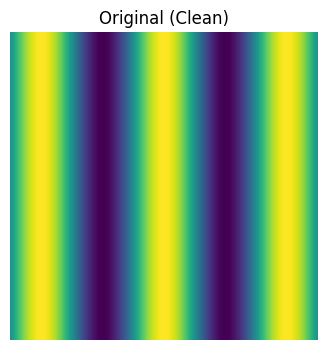

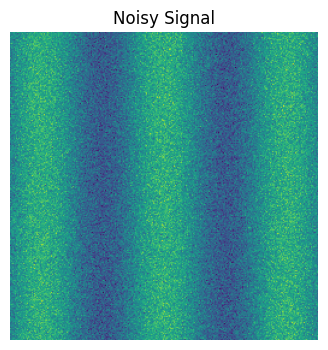

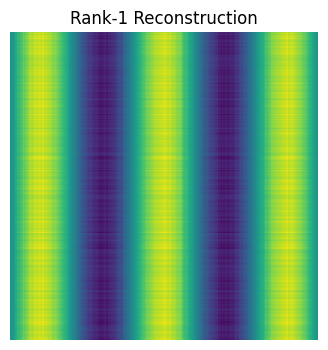

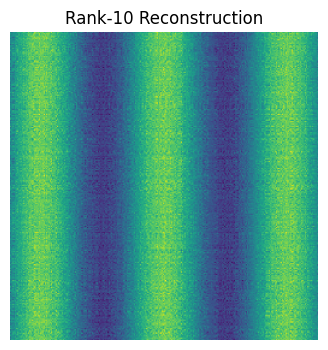

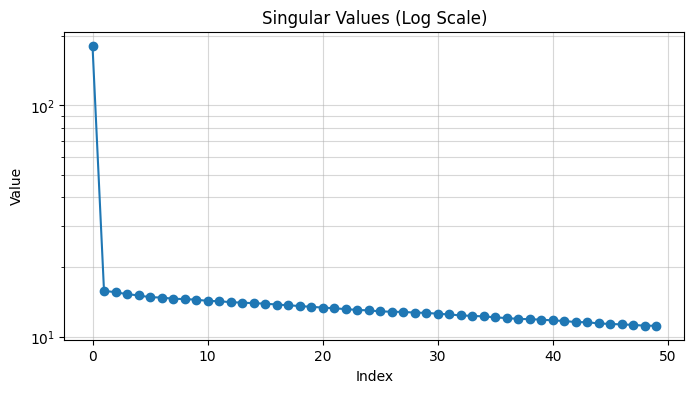

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a clean, low-rank synthetic signal (a 2D sine wave)
x = np.linspace(0, 5 * np.pi, 256)
y = np.linspace(0, 5 * np.pi, 256)
X, Y = np.meshgrid(x, y)
clean_data = np.sin(X)  # This is a rank-1 matrix

# 2. Add heavy Gaussian noise
np.random.seed(42)
noise = np.random.normal(0, 0.5, clean_data.shape)
noisy_data = clean_data + noise

# 3. Compute SVD
U, S, Vt = np.linalg.svd(noisy_data, full_matrices=False)

# 4. Reconstruct using different ranks
def reconstruct(rank):
    return U[:, :rank] @ np.diag(S[:rank]) @ Vt[:rank, :]

# Define the datasets to display
results = {
    "Original (Clean)": clean_data,
    "Noisy Signal": noisy_data,
    "Rank-1 Reconstruction": reconstruct(1),
    "Rank-10 Reconstruction": reconstruct(10)
}

# 5. Plot the results in separate plots
for title, data in results.items():
    plt.figure(figsize=(5, 4))
    plt.imshow(data, cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()

# Plot Singular Values to show the 'elbow'
plt.figure(figsize=(8, 4))
plt.semilogy(S[:50], 'o-')
plt.title("Singular Values (Log Scale)")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True, which='both', ls='-', alpha=0.5)
plt.show()